<a href="https://colab.research.google.com/github/kirthankulkarni-bit/assip-ML-stress-monitoring/blob/main/multiple_subjects.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import butter, filtfilt, find_peaks
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, recall_score, precision_score

# mount drive
drive.mount('/content/drive')


Mounted at /content/drive


In [11]:
# slight variation of previous data filtering code but in one function

def process_subject(subject_id, file_path):
    print(f"processing {subject_id}")

    # load new data
    with open(file_path, 'rb') as f:
        subject_data = pickle.load(f, encoding='latin1')

    raw_eda = subject_data['signal']['wrist']['EDA'].flatten() # change to wrist sensors instead of chest sensors
    raw_bvp = subject_data['signal']['wrist']['BVP'].flatten()
    labels = subject_data['label'].flatten()

    # sampling rate constants
    fs_eda, fs_bvp, fs_label = 4, 64, 700

    # EDA filters (1hz lowpass to clean, 0.05hz highpass for phasic)
    b_low, a_low = butter(4, 1.0 / (0.5 * fs_eda), btype='low')
    clean_eda = filtfilt(b_low, a_low, raw_eda)
    b_high, a_high = butter(4, 0.05 / (0.5 * fs_eda), btype='high')
    phasic_eda = filtfilt(b_high, a_high, clean_eda)

    # BVP Filter (0.5 - 8hz bandpass)
    b_band, a_band = butter(4, [0.5 / (0.5 * fs_bvp), 8.0 / (0.5 * fs_bvp)], btype='band')
    clean_bvp = filtfilt(b_band, a_band, raw_bvp)

    # window constants
    window_size = 60
    step_size = 30
    total_sec = len(labels) // fs_label

    features_list = []

    # sliding window loop
    for start in range(0, total_sec - window_size, step_size):
        eda_slice = phasic_eda[start * fs_eda : (start + window_size) * fs_eda]
        bvp_slice = clean_bvp[start * fs_bvp : (start + window_size) * fs_bvp]
        label_slice = labels[start * fs_label : (start + window_size) * fs_label]

        majority_label = np.bincount(label_slice).argmax()

        if majority_label in [1, 2]:
            bvp_peaks, _ = find_peaks(bvp_slice, distance=32)

            features_list.append({
                'subject': subject_id,
                'eda_mean': np.mean(eda_slice),
                'eda_std': np.std(eda_slice),
                'eda_max': np.max(eda_slice),
                'eda_min': np.min(eda_slice),
                'bvp_hr_bpm': len(bvp_peaks),
                'bvp_std': np.std(bvp_slice),
                'label': majority_label
            })

    df = pd.DataFrame(features_list)

    # z-score normalization (s2 training -> s3 testing fix) -> rest-baseline normalization (loso fix) -> revert back but remove bvp_std feature
    feature_cols = ['eda_mean', 'eda_std', 'eda_max', 'eda_min', 'bvp_hr_bpm'] # standardize each feature column independently for each subject, also implement feature pruning technique and remove bvp_std feature

    for col in feature_cols: # loop through each feature
      # calculate mean and standard deviation
      col_mean = df[col].mean()
      col_std = df[col].std()

      # apply the z-score scaling to all windows
      if col_std != 0:
        df[col] = (df[col] - col_mean) / col_std
      else:
        df[col] = 0.0

    df = df.drop(columns=['bvp_std'])

    print(f"done with {subject_id}: normalized {len(df)} windows (mean -> 0 and std -> 1)")
    return df


In [4]:
!unzip -q "/content/drive/MyDrive/ASSIP/archive.zip" -d "/content/"

In [5]:
subjects = ['S2', 'S3', 'S4', 'S5', 'S6', 'S10']
subject_dfs = []

for sub in subjects:
  path = f'/content/WESAD/{sub}/{sub}.pkl'
  subject_df = process_subject(sub, path)
  subject_dfs.append(subject_df)

df_master = pd.concat(subject_dfs, ignore_index=True)
print(f"master dataset created")


processing S2
done with S2: normalized 59 windows (mean -> 0 and std -> 1)
processing S3
done with S3: normalized 60 windows (mean -> 0 and std -> 1)
processing S4
done with S4: normalized 60 windows (mean -> 0 and std -> 1)
processing S5
done with S5: normalized 61 windows (mean -> 0 and std -> 1)
processing S6
done with S6: normalized 61 windows (mean -> 0 and std -> 1)
processing S10
done with S10: normalized 63 windows (mean -> 0 and std -> 1)
master dataset created


In [ ]:
print("training on s2 data")
print("testing on s3 data\n")

# training on subject 2 data
x_train = df_s2.drop(columns=['label', 'subject'])
y_train = df_s2['label']

# test purely on subject 3 data (see how model performs when encountering completely new data)
x_test = df_s3.drop(columns=['label', 'subject'])
y_test = df_s3['label']

rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(x_train, y_train)
y_pred = rf_model.predict(x_test)

print("Classification Report")
print(classification_report(y_test, y_pred, target_names=['Baseline', 'Stress']))

# generate and display the confusion matrix for model evaluation
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 4)) # changed size from 5 to 10

plt.subplot(1, 2, 1) # 1 row, 2 column layout for subplot
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Baseline', 'Stress'],
            yticklabels=['Baseline', 'Stress'])
plt.title('s2 training -> s3 testing')
plt.ylabel('Actual State')
plt.xlabel('Predicted State')

# plot new feature importance
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]
features_ranked = [x_train.columns[k] for k in indices]

plt.subplot(1, 2, 2)
sns.barplot(x=importances[indices], y=features_ranked, palette='viridis')
plt.title('Normalized Feature Importance')
plt.xlabel('Relative Importance')

plt.tight_layout()
plt.show()

training on s2 data
testing on s3 data



NameError: name 'df_s2' is not defined

fold results for S2: accuracy: 0.85, stress recall: 0.76, precision: 0.80
fold results for S3: accuracy: 0.65, stress recall: 0.41, precision: 0.53
fold results for S4: accuracy: 1.00, stress recall: 1.00, precision: 1.00
fold results for S5: accuracy: 0.93, stress recall: 1.00, precision: 0.84
fold results for S6: accuracy: 0.97, stress recall: 0.95, precision: 0.95
fold results for S10: accuracy: 0.65, stress recall: 0.50, precision: 0.55


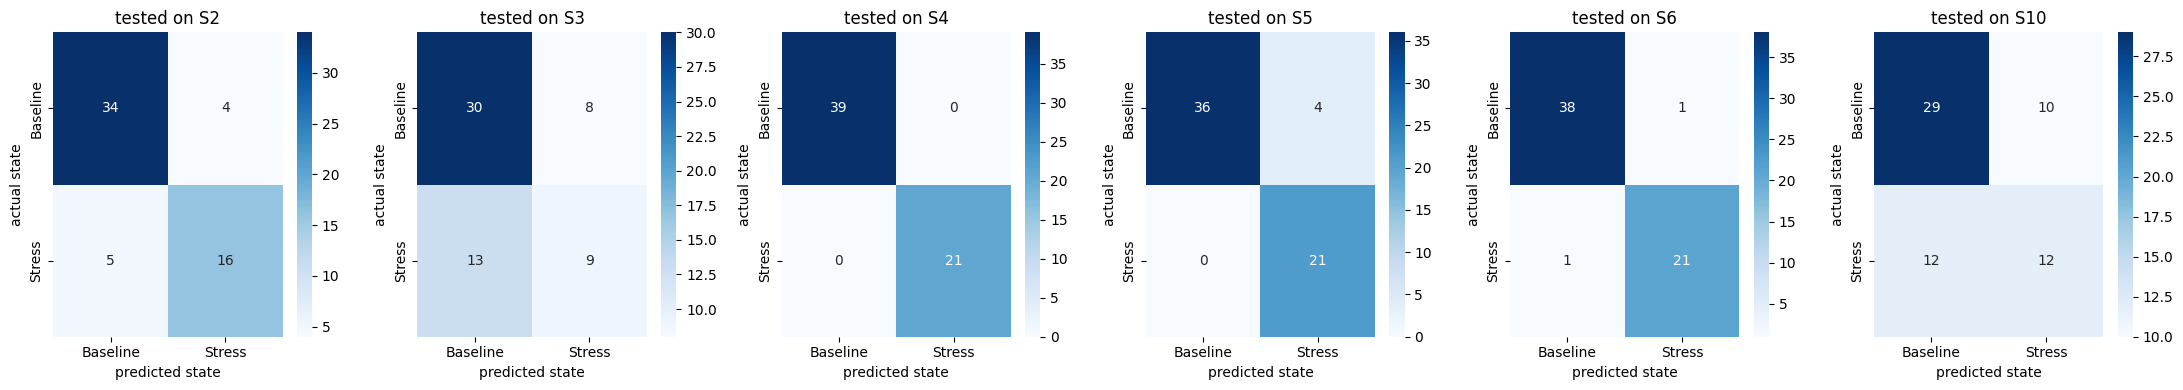

In [6]:
# script for loso loop (leave one subject out); since there are 3 subjects now (s2, s3, s10), we can train on two and test on one to improve model intelligence -> updated pool to 6 subjects (s2, s3, s4, s5, s6, s10)
loso_results = {}
all_importances = []

# setting up subplots to display confusion matrices side-by-side
fig, axes = plt.subplots(1, len(subjects), figsize = (22, 4))

# loop through subjects so all possibilities of folds are considered
for idx, test_subject in enumerate(subjects):

  # train on 2 subjects, test on the last subject
  train_data = df_master[df_master['subject'] != test_subject]
  test_data = df_master[df_master['subject'] == test_subject]

  x_train = train_data.drop(columns=['label', 'subject'])
  y_train = train_data['label']

  x_test = test_data.drop(columns=['label', 'subject'])
  y_test = test_data['label']

  # train the random forest
  rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
  rf.fit(x_train, y_train)
  y_pred = rf.predict(x_test) # predict

  # track feature importance across multple folds
  all_importances.append(rf.feature_importances_)

  # evaluate performance
  acc = accuracy_score(y_test, y_pred)
  rec = recall_score(y_test, y_pred, pos_label=2, zero_division=0)
  prec = precision_score(y_test, y_pred, pos_label=2, zero_division=0)

  loso_results[test_subject] = {
      'accuracy': acc,
      'recall_stress': rec,
      'precision_stress': prec
  }

  print(f"fold results for {test_subject}: accuracy: {acc:.2f}, stress recall: {rec:.2f}, precision: {prec:.2f}")

  # plot individual confusion matrix heatmap
  cm = confusion_matrix(y_test, y_pred)
  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Baseline', 'Stress'],
                yticklabels=['Baseline', 'Stress'])
  axes[idx].set_title(f'tested on {test_subject}')
  axes[idx].set_ylabel('actual state')
  axes[idx].set_xlabel('predicted state')

plt.tight_layout()
plt.show()



In [13]:
!pip install micromlgen # install this library for converting python random forest model to highly optimized c++ decision trees

In [15]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from micromlgen import port

df_master['label'] = df_master['label'].map({1: 0, 2: 1})

# using all 6 subjects to train best model for final model
x_train_final = df_master.drop(columns=['label', 'subject'])
y_train_final = df_master['label']

# train Random Forest on same parameters as before but limit max_depth to keep C++ code small enough for microcontroller
rf_final = RandomForestClassifier(n_estimators=10, max_depth = 6, class_weight='balanced', random_state=42)
rf_final.fit(x_train_final, y_train_final)

# convert to c++ using micromlgen library
c_code = port(rf_final, classmap={1: "baseline", 2: "stress"}, classname = "stressModel")

# save generated c++ code to a header file
file_path = '/content/StressModel.h'
with open(file_path, 'w') as f:
  f.write(c_code)

print(f"model exported to {file_path}")

model exported to /content/StressModel.h
